In [1]:
#To-DO
  #Clean the data (remove duplicates and null values,convert column datatypes to appropriate data types)
  #Prepare the data for the model
    #Regression model
          #Predict the dine rating based on other features

## EDA(Exploratory Data Analysis)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

import warnings
warnings.filterwarnings('ignore')

In [5]:
#Dataset from : https://www.kaggle.com/datasets/nagar500/pune-restaurants-zomato.

df = pd.read_csv("C:/Users/SOFT/Documents/Data sets/zomato_outlet_final.csv")
df.head()

,link,rest_name,rest_type,loc,dine_rating,dine_reviews,delivery_rating,delivery_reviews,cuisine,cost,liked
0,https://www.zomato.com/pune/mix@36-the-westin-...,Mix@36 - The Westin\r\r\n ...,Lounge,"The Westin, Mundhwa",4.2,(707 Reviews),NaN,NaN,"North Indian,Continental,Asian,Finger Food,","Rs. 4,300","Cocktails, Chaat, Beer"
1,https://www.zomato.com/pune/kangan-the-westin-...,Kangan - The Westin\r\r\n ...,Fine Dining,"The Westin, Mundhwa",4.1,(344 Reviews),NaN,NaN,"North Indian,Mughlai,","Rs. 3,500","Biryani, Veg Platter, Dal Makhani, Butter Chic..."
2,https://www.zomato.com/pune/coriander-kitchen-...,Coriander Kitchen - Conrad Pune\r\r\n ...,Fine Dining,"Conrad Pune, Bund Garden Road",4.5,(541 Reviews),NaN,NaN,"Mediterranean,Asian,North Indian,","Rs. 3,200","Pasta, Panipuri, Waffles, Pizza, Salad, Chaat,..."
3,https://www.zomato.com/pune/the-market-the-wes...,The Market - The Westin\r\r\n ...,Fine Dining,"The Westin, Mundhwa",4.0,(55 Reviews),NaN,NaN,"Asian,European,North Indian,","Rs. 3,200","Vanilla Ice Cream, Chaat, Sushi"
4,https://www.zomato.com/pune/vandaag-vivanta-pu...,Vandaag - Vivanta Pune\r\r\n ...,"Pub,Casual Dining","Vivanta Pune, Hinjewadi",3.9,(113 Reviews),NaN,NaN,"Finger Food,Continental,","Rs. 3,100","Cocktails, Beer, Peri Peri Chicken, Fish, Veg ..."


In [5]:
print(df.shape)

(5433, 11)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5433 entries, 0 to 5432
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   link              5433 non-null   object 
 1   rest_name         5433 non-null   object 
 2   rest_type         4336 non-null   object 
 3   loc               5433 non-null   object 
 4   dine_rating       4829 non-null   float64
 5   dine_reviews      4829 non-null   object 
 6   delivery_rating   2539 non-null   float64
 7   delivery_reviews  2539 non-null   object 
 8   cuisine           5433 non-null   object 
 9   cost              5433 non-null   object 
 10  liked             2603 non-null   object 
dtypes: float64(2), object(9)
memory usage: 467.0+ KB
None


In [7]:
pd.DataFrame((df.isna().sum()/df.shape[0]*100).round(2).sort_values(ascending = False),columns=['Percentage Missing'])

,Percentage Missing
delivery_rating,53.27
delivery_reviews,53.27
liked,52.09
rest_type,20.19
dine_rating,11.12
dine_reviews,11.12
link,0.00
rest_name,0.00
loc,0.00
cuisine,0.00


> delivary_rating,delivery_reviews and liked columns have higher number of missing values(>50%)

#### Dealing wth missing and unnecessary data

In [10]:
df.drop(['liked','delivery_rating','delivery_reviews','link'],inplace=True,axis=1)

In [11]:
df.dropna(inplace=True)
df.shape

(4004, 7)

In [12]:
df.isna().sum()

rest_name       0
rest_type       0
loc             0
dine_rating     0
dine_reviews    0
cuisine         0
cost            0
dtype: int64

#### Cleaning the data

In [14]:
df['rest_name'] = df['rest_name'].apply(lambda x : x.replace("\r\r\n" , ""))
df['rest_name'] = df['rest_name'].apply(lambda x : x.replace("\r\n" , ""))
df['rest_name']

0       Mix@36 - The Westin                           ...
1       Kangan - The Westin                           ...
2       Coriander Kitchen - Conrad Pune               ...
3       The Market - The Westin                       ...
4       Vandaag - Vivanta Pune                        ...
                              ...                        
5428    Murli Pure Veg                                ...
5429    The Irani Cafe Restaurant                     ...
5430    Hotel Shilpa Gavran                           ...
5431    MH 12 Pav Bhaji & Juice Center                ...
5432       Liyo China                                    
Name: rest_name, Length: 4004, dtype: object

In [15]:
def clean_data(cols, str_to_replace):
           
    for col in cols:
        df[col] = [str(x).replace(str_to_replace,"") for x in df[col]]    
        
    return df

def extract_digit(cols):
    
    for col in cols:
        df[col] = df[col].str.extract(r'(\d+)', expand=True)
        
    return df

df = clean_data(['cost', 'dine_reviews'], ",")
df = extract_digit(['cost', 'dine_reviews'])

In [55]:
df.head()

,rest_name,rest_type,Area,dine_rating,dine_reviews,cuisine,cost,rest_type_list
0,Mix@36 - The Westin ...,Lounge,Mundhwa,4.2,707,"North Indian,Continental,Asian,Finger Food,",4300,[Lounge]
1,Kangan - The Westin ...,Fine Dining,Mundhwa,4.1,344,"North Indian,Mughlai,",3500,[Fine Dining]
2,Coriander Kitchen - Conrad Pune ...,Fine Dining,Bund Garden Road,4.5,541,"Mediterranean,Asian,North Indian,",3200,[Fine Dining]
3,The Market - The Westin ...,Fine Dining,Mundhwa,4.0,55,"Asian,European,North Indian,",3200,[Fine Dining]
4,Vandaag - Vivanta Pune ...,"Pub,Casual Dining",Hinjewadi,3.9,113,"Finger Food,Continental,",3100,"[Pub, Casual Dining]"


#### Changing column data types

In [18]:
df.dtypes

rest_name        object
rest_type        object
loc              object
dine_rating     float64
dine_reviews     object
cuisine          object
cost             object
dtype: object

In [19]:
df[['dine_reviews','cost']] = df[['dine_reviews','cost']].apply(pd.to_numeric)

In [20]:
df.dtypes

rest_name        object
rest_type        object
loc              object
dine_rating     float64
dine_reviews      int64
cuisine          object
cost              int64
dtype: object

#### Adding new columns

In [22]:
df['Area'] = df['loc'].apply(lambda x : x.split(",")[-1].strip())

In [23]:
area_col = df.pop('Area')
df.insert(2,'Area',area_col)
df.drop("loc",inplace=True,axis=1)

In [24]:
df.head()

,rest_name,rest_type,Area,dine_rating,dine_reviews,cuisine,cost
0,Mix@36 - The Westin ...,Lounge,Mundhwa,4.2,707,"North Indian,Continental,Asian,Finger Food,",4300
1,Kangan - The Westin ...,Fine Dining,Mundhwa,4.1,344,"North Indian,Mughlai,",3500
2,Coriander Kitchen - Conrad Pune ...,Fine Dining,Bund Garden Road,4.5,541,"Mediterranean,Asian,North Indian,",3200
3,The Market - The Westin ...,Fine Dining,Mundhwa,4.0,55,"Asian,European,North Indian,",3200
4,Vandaag - Vivanta Pune ...,"Pub,Casual Dining",Hinjewadi,3.9,113,"Finger Food,Continental,",3100


In [105]:
df.groupby(['Area','rest_type'])['cost'].mean().sort_values(ascending=False)

Area                        rest_type                 
Mundhwa                     Fine Dining                   3300.000000
Hinjewadi                   Pub,Casual Dining             3100.000000
DoubleTree By Hilton Hotel  Lounge,Fine Dining            3000.000000
Bund Garden Road            Bar                           3000.000000
                            Fine Dining                   2988.888889
                                                             ...     
Sinhgad Road                Dessert Parlor,Quick Bites     100.000000
Hinjawadi                   Beverage Shop                  100.000000
Budhwar Peth                Beverage Shop                  100.000000
Kondhwa                     Food Truck                     100.000000
Katraj                      Beverage Shop                  100.000000
Name: cost, Length: 825, dtype: float64

In [25]:
df['Area'].unique()

array(['Mundhwa', 'Bund Garden Road', 'Hinjewadi', 'Nagar Road',
       'Yerwada', 'DoubleTree By Hilton Hotel', 'Koregaon Park',
       'Marriott Suites Pune', 'Senapati Bapat Road', 'Magarpatta',
       'Lonavala', 'Kharadi', 'Hadapsar', 'Wakad', 'East Street',
       'Viman Nagar', 'Hotel Royal Orchid Central Kalyani Nagar',
       'Della Adventure Resort', 'The Pride Hotel Shivaji Nagar',
       'Hotel Orritel Convention & Wedding Resort', 'Kondhwa', 'Baner',
       'Chinchwad', 'Shivaji Nagar', 'Hinjawadi', 'Aundh', 'Kondhawa',
       'Kalyani Nagar', 'Old Mumbai-Pune Highway', 'FC Road',
       'Ambrosia Resort and Spa', 'Pancard Clubs', 'Bavdhan', 'Ravet',
       'Lemon Tree Hotel', 'Sus', 'Pimple Saudagar', 'Yerawada', 'Camp',
       'Pune University', 'Chakan', 'Khandala', 'Pune', 'Lavasa',
       'Dange Chowk', 'Pashan', 'Balewadi', 'Kothrud', 'Dhole Patil Road',
       'Shukrawar Peth', 'Grand Exotica Business Hotel', 'Pimpri',
       'Swargate', 'Law College Road', 'Deccan 

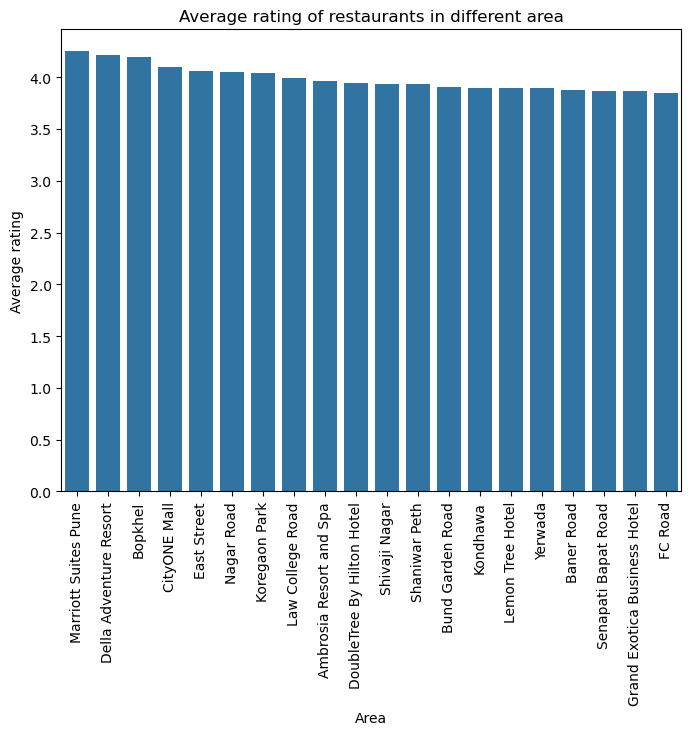

In [69]:
area_group = df.groupby("Area")['dine_rating'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize = (8,6))
sns.barplot(area_group)
plt.title('Average rating of restaurants in different area')
plt.xlabel('Area')
plt.ylabel('Average rating')
plt.tick_params(axis='x', rotation=90)
plt.savefig('img1.png',bbox_inches='tight')

> Marriote suites,Della resort,Bopkhel are among highest rated restaurants in pune on zomato

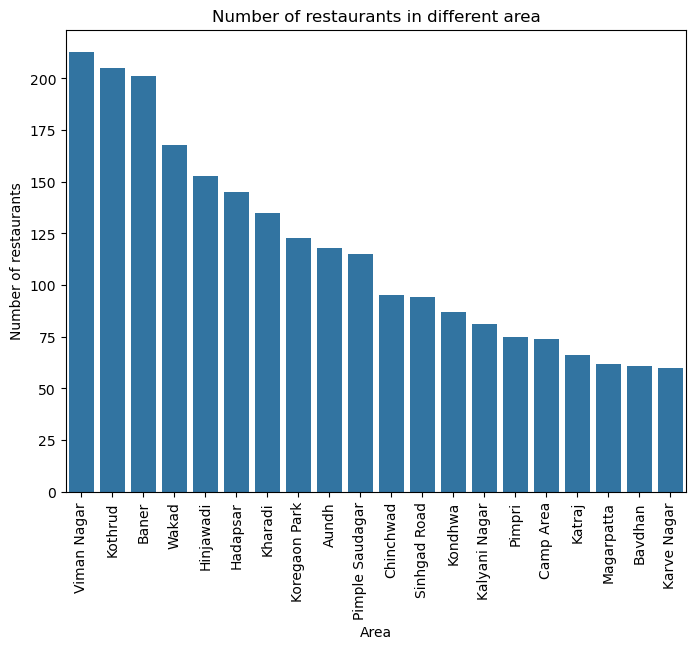

In [73]:
area_group = df.groupby("Area")['rest_name'].count().sort_values(ascending=False).head(20)

plt.figure(figsize = (8,6))
sns.barplot(area_group)
plt.title('Number of restaurants in different area')
plt.xlabel('Area')
plt.ylabel('Number of restaurants')
plt.tick_params(axis='x', rotation=90)
plt.savefig('img2.png',bbox_inches='tight')

> Viman Nagar,Kothrud and Baner are hotspots for opening a restaurant

Text(0.5, 1.0, 'Distribution of different types of restaurant')

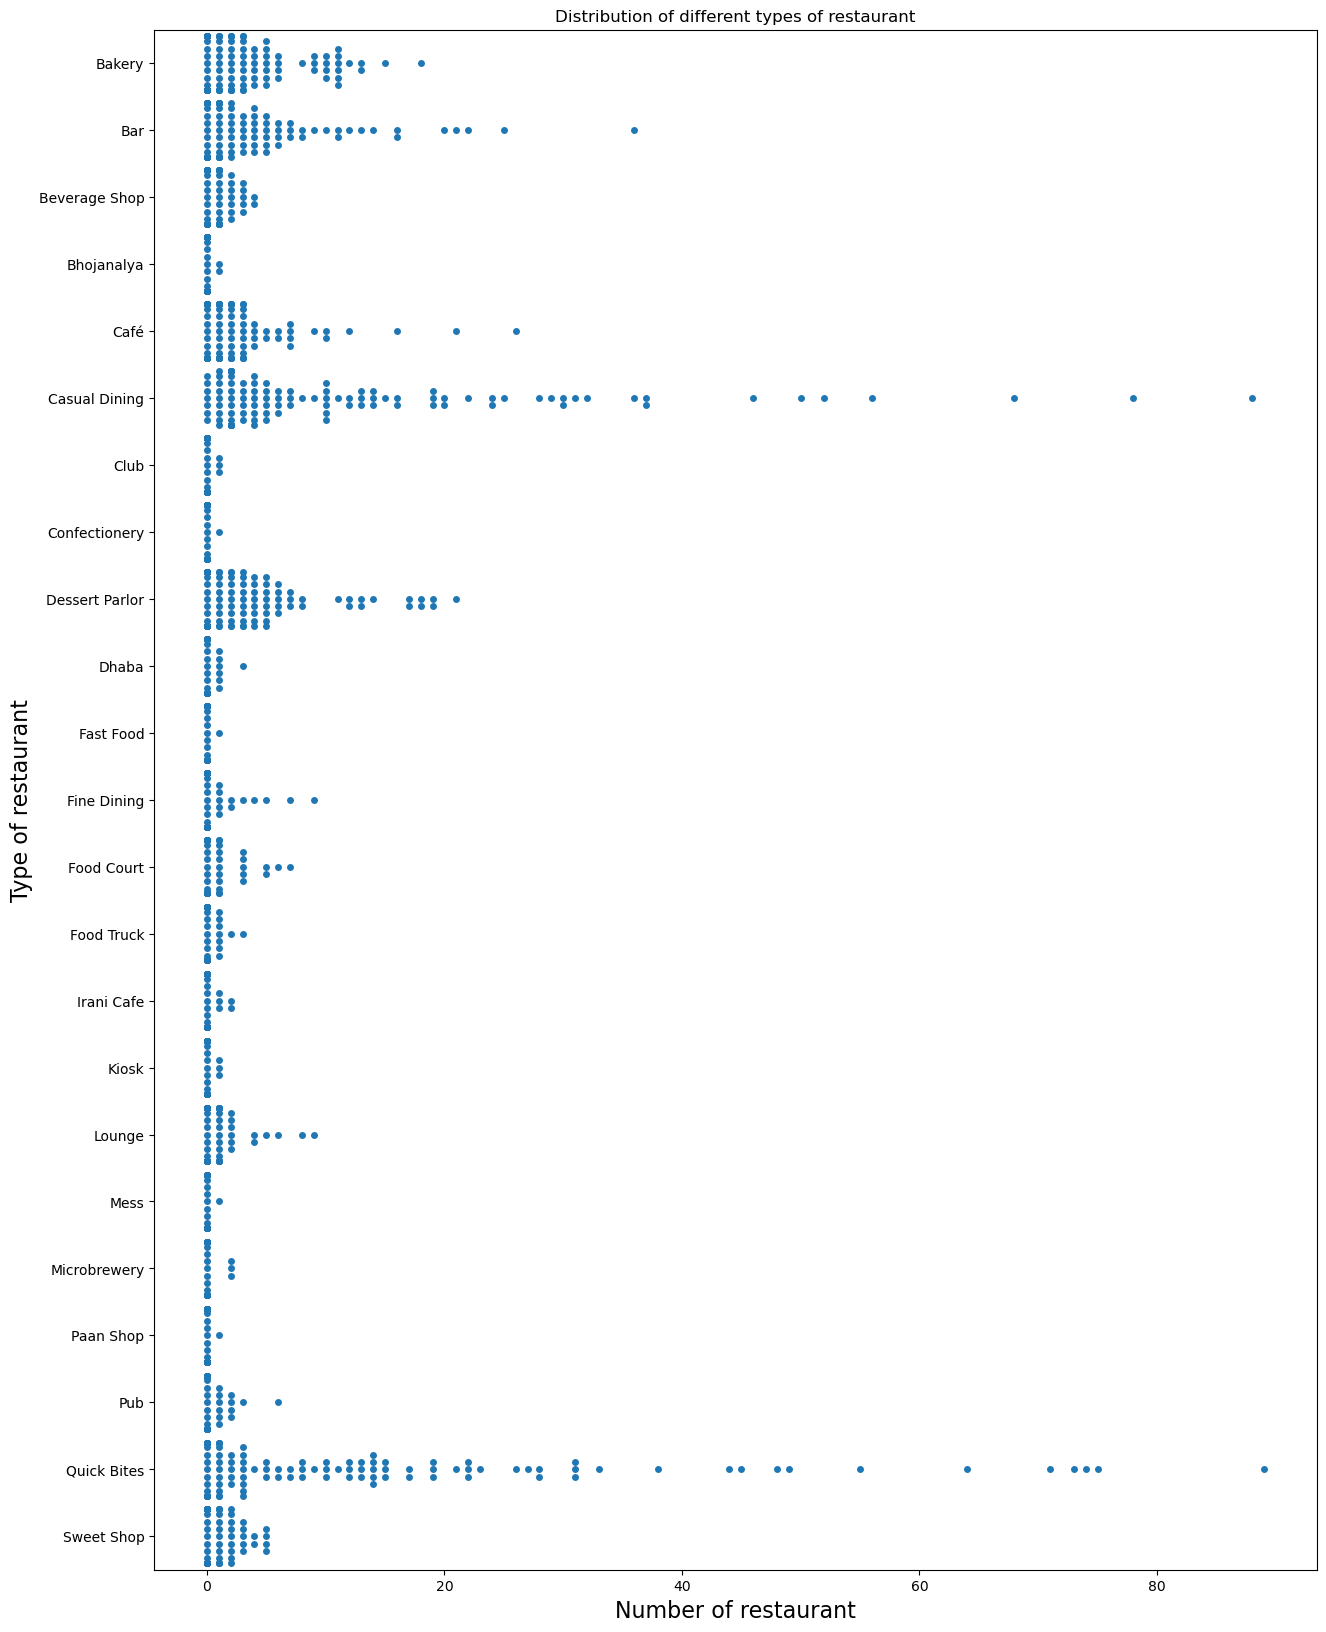

In [37]:
plt.figure(figsize=(15,20))
ax = sns.swarmplot(x="vals", y="cols", data=df_hood)
ax.set_xlabel('Number of restaurant', fontsize=16)
ax.set_ylabel('Type of restaurant', fontsize=16)
ax.set_title('Distribution of different types of restaurant')

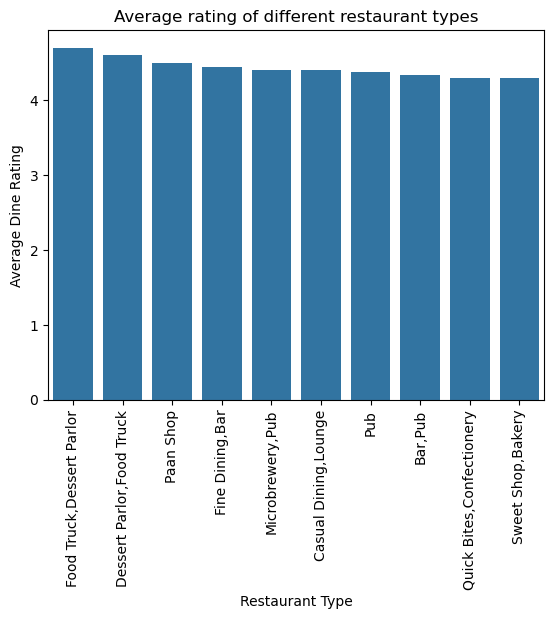

In [38]:
rest_group = df.groupby("rest_type")['dine_rating'].mean().sort_values(ascending = False).head(10)

sns.barplot(rest_group)
plt.title('Average rating of different restaurant types')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Dine Rating')
plt.tick_params(axis='x', rotation=90)

Text(0.5, 1.0, 'No of restaurants in Locality')

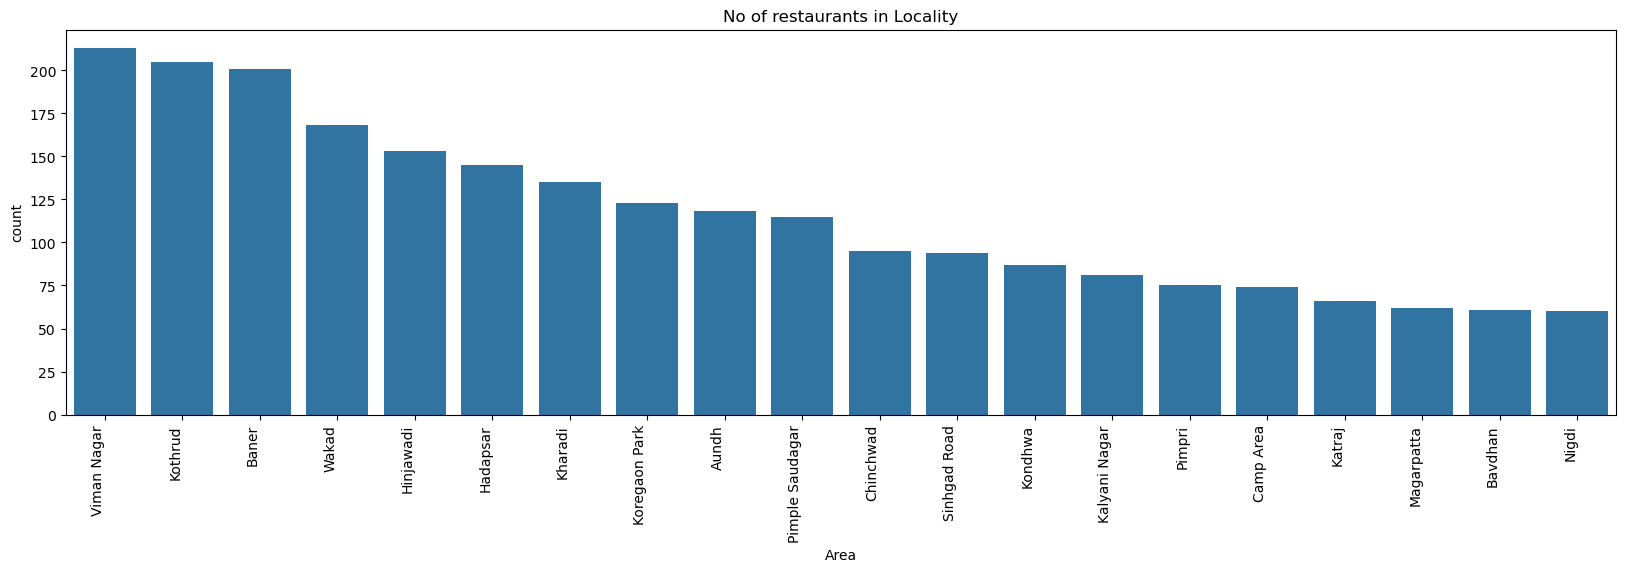

In [79]:
plt.figure(figsize=(20,5))
locations=df['Area'].value_counts()[:20]
g = sns.barplot(locations)
g.set_xticklabels(g.get_xticklabels(), rotation=90, ha="right")
g
plt.title("No of restaurants in Locality")

### For model
- predictors = rest_type,Area,cuisine and cost
- target = dine_rating

In [193]:
df2 = df.copy()
df2.head()

,rest_name,rest_type,Area,dine_rating,dine_reviews,cuisine,cost,rest_type_list
0,Mix@36 - The Westin ...,Lounge,Mundhwa,4.2,707,"North Indian,Continental,Asian,Finger Food,",4300,[Lounge]
1,Kangan - The Westin ...,Fine Dining,Mundhwa,4.1,344,"North Indian,Mughlai,",3500,[Fine Dining]
2,Coriander Kitchen - Conrad Pune ...,Fine Dining,Bund Garden Road,4.5,541,"Mediterranean,Asian,North Indian,",3200,[Fine Dining]
3,The Market - The Westin ...,Fine Dining,Mundhwa,4.0,55,"Asian,European,North Indian,",3200,[Fine Dining]
4,Vandaag - Vivanta Pune ...,"Pub,Casual Dining",Hinjewadi,3.9,113,"Finger Food,Continental,",3100,"[Pub, Casual Dining]"


In [195]:
#dropping other columns
df2.drop(['rest_name','rest_type_list'],axis=1,inplace=True)
df2.head()

,rest_type,Area,dine_rating,dine_reviews,cuisine,cost
0,Lounge,Mundhwa,4.2,707,"North Indian,Continental,Asian,Finger Food,",4300
1,Fine Dining,Mundhwa,4.1,344,"North Indian,Mughlai,",3500
2,Fine Dining,Bund Garden Road,4.5,541,"Mediterranean,Asian,North Indian,",3200
3,Fine Dining,Mundhwa,4.0,55,"Asian,European,North Indian,",3200
4,"Pub,Casual Dining",Hinjewadi,3.9,113,"Finger Food,Continental,",3100


### Encode Categorical variables-rest_type,Area,cuisine

In [198]:
for col in ['rest_type', 'Area']:
    freq_encoding = df2[col].value_counts().to_dict()
    df2[col] = df2[col].map(freq_encoding)

In [200]:
df2

,rest_type,Area,dine_rating,dine_reviews,cuisine,cost
0,27,35,4.2,707,"North Indian,Continental,Asian,Finger Food,",4300
1,30,35,4.1,344,"North Indian,Mughlai,",3500
2,30,31,4.5,541,"Mediterranean,Asian,North Indian,",3200
3,30,35,4.0,55,"Asian,European,North Indian,",3200
4,10,17,3.9,113,"Finger Food,Continental,",3100
...,...,...,...,...,...,...
5428,913,94,3.1,22,"South Indian,Chinese,North Indian,",550
5429,913,213,2.9,80,"Mughlai,Iranian,",800
5430,913,75,3.8,90,"Chinese,Fast Food,North Indian,",500
5431,1445,54,3.1,24,"Beverages,Chinese,Street Food,Fast Food,",250


In [202]:
df2['cuisine'] = df2['cuisine'].str.split(',')
df2['cuisine']

0       [North Indian, Continental, Asian, Finger Food, ]
1                               [North Indian, Mughlai, ]
2                  [Mediterranean, Asian, North Indian, ]
3                       [Asian, European, North Indian, ]
4                            [Finger Food, Continental, ]
                              ...                        
5428              [South Indian, Chinese, North Indian, ]
5429                                 [Mughlai, Iranian, ]
5430                 [Chinese, Fast Food, North Indian, ]
5431       [Beverages, Chinese, Street Food, Fast Food, ]
5432                                    [Thai, Chinese, ]
Name: cuisine, Length: 4004, dtype: object

In [204]:
from collections import Counter
all_cuisines = sum(df2['cuisine'], [])  
cuisine_counts = Counter(all_cuisines)   #crreate a dictonary of frequency of each data

In [206]:
#top 10 cuisines
top_10_cuisines = set([cuisine for cuisine, _ in cuisine_counts.most_common(10)])

In [208]:
#replace less common cuisines with 'other'
df2['cuisine_filtered'] = df2['cuisine'].apply(
    lambda cuisines: [c if c in top_10_cuisines else 'Other' for c in cuisines])

In [210]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
cuisine_encoded = pd.DataFrame(mlb.fit_transform(df2['cuisine_filtered']),
                               columns=mlb.classes_,
                               index=df2.index)

In [212]:
df2.head()

,rest_type,Area,dine_rating,dine_reviews,cuisine,cost,cuisine_filtered
0,27,35,4.2,707,"[North Indian, Continental, Asian, Finger Food, ]",4300,"[North Indian, Continental, Other, Other, ]"
1,30,35,4.1,344,"[North Indian, Mughlai, ]",3500,"[North Indian, Mughlai, ]"
2,30,31,4.5,541,"[Mediterranean, Asian, North Indian, ]",3200,"[Other, Other, North Indian, ]"
3,30,35,4.0,55,"[Asian, European, North Indian, ]",3200,"[Other, Other, North Indian, ]"
4,10,17,3.9,113,"[Finger Food, Continental, ]",3100,"[Other, Continental, ]"


In [214]:
df2 = pd.concat([df2.drop(['cuisine', 'cuisine_filtered'], axis=1), cuisine_encoded], axis=1)

In [216]:
df2.head()

,rest_type,Area,dine_rating,dine_reviews,cost,,Bakery,Beverages,Chinese,Continental,Desserts,Fast Food,Mughlai,North Indian,Other,Street Food
0,27,35,4.2,707,4300,1,0,0,0,1,0,0,0,1,1,0
1,30,35,4.1,344,3500,1,0,0,0,0,0,0,1,1,0,0
2,30,31,4.5,541,3200,1,0,0,0,0,0,0,0,1,1,0
3,30,35,4.0,55,3200,1,0,0,0,0,0,0,0,1,1,0
4,10,17,3.9,113,3100,1,0,0,0,1,0,0,0,0,1,0


In [218]:
df2.drop([""],axis = 1,inplace=True)

In [220]:
df2

,rest_type,Area,dine_rating,dine_reviews,cost,Bakery,Beverages,Chinese,Continental,Desserts,Fast Food,Mughlai,North Indian,Other,Street Food
0,27,35,4.2,707,4300,0,0,0,1,0,0,0,1,1,0
1,30,35,4.1,344,3500,0,0,0,0,0,0,1,1,0,0
2,30,31,4.5,541,3200,0,0,0,0,0,0,0,1,1,0
3,30,35,4.0,55,3200,0,0,0,0,0,0,0,1,1,0
4,10,17,3.9,113,3100,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5428,913,94,3.1,22,550,0,0,1,0,0,0,0,1,1,0
5429,913,213,2.9,80,800,0,0,0,0,0,0,1,0,1,0
5430,913,75,3.8,90,500,0,0,1,0,0,1,0,1,0,0
5431,1445,54,3.1,24,250,0,1,1,0,0,1,0,0,0,1


In [222]:
from sklearn.model_selection import train_test_split

X=df2.drop(['dine_rating'],axis=1)
y=df2['dine_rating']

X_test,X_train,y_test,y_train = train_test_split(X,y,test_size=0.2,random_state=42)

print("X test size " , X_test.shape)
print("y test size " , y_test.shape)
print("X train size " , X_train.shape)
print("y train size " , y_train.shape)

X test size  (3203, 14)
y test size  (3203,)
X train size  (801, 14)
y train size  (801,)


In [224]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [226]:
#returns a metric of model performance
print(model.score(X_test,y_test))

0.24844508380472696


In [228]:
# Make predictions on the testing data.
y_pred = model.predict(X_test)

In [230]:
from sklearn.metrics import mean_squared_error,r2_score

r2 = r2_score(y_test,y_pred)
r2

0.24844508380472696

In [256]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: -20481640.108400285
MAE: 1394.6146847138184
MSE: 5295161.882181759


In [252]:
from sklearn.preprocessing import StandardScaler

X=df2.drop(['dine_rating'],axis=1)
y=df2['dine_rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

# Fit only on training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.24492546807404014
MAE: 0.35258991523125105
MSE: 0.19521101158347842


In [246]:
df_model = df.copy()
df_model.head()

,rest_name,rest_type,Area,dine_rating,dine_reviews,cuisine,cost,rest_type_list
0,Mix@36 - The Westin ...,Lounge,Mundhwa,4.2,707,"North Indian,Continental,Asian,Finger Food,",4300,[Lounge]
1,Kangan - The Westin ...,Fine Dining,Mundhwa,4.1,344,"North Indian,Mughlai,",3500,[Fine Dining]
2,Coriander Kitchen - Conrad Pune ...,Fine Dining,Bund Garden Road,4.5,541,"Mediterranean,Asian,North Indian,",3200,[Fine Dining]
3,The Market - The Westin ...,Fine Dining,Mundhwa,4.0,55,"Asian,European,North Indian,",3200,[Fine Dining]
4,Vandaag - Vivanta Pune ...,"Pub,Casual Dining",Hinjewadi,3.9,113,"Finger Food,Continental,",3100,"[Pub, Casual Dining]"


In [250]:
from sklearn.ensemble import RandomForestRegressor

# Drop irrelevant columns
df_model = df.drop(columns=['rest_name', 'dine_reviews'])

# Drop rows with missing values in key columns
df_model = df_model.dropna(subset=['dine_rating', 'rest_type'])

# Encode categorical features
for col in ['rest_type', 'Area', 'cuisine']:
    df_model[col] = df_model[col].astype('category').cat.codes

# Prepare features and target
X = df_model[['rest_type', 'Area', 'cuisine', 'cost']]
y = df_model['dine_rating']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and evaluation
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

rf_mse, rf_r2

(0.18593747170963842, 0.2807954414056526)